# 🔍 Credit Card Fraud Detection — KNN vs Logistic Regression
**Statistics & Probability — Final Research Project**
Team Nekat Part 100 · Felicia Sword · 0706012410012 · May 2026

---
**Objective:** Compare K-Nearest Neighbor and Logistic Regression for fraud classification under baseline and SMOTE conditions.
**Dataset:** Sparkov Credit Card Transactions (1.85M transactions, ~0.58% fraud rate)


## Stage 1 · Setup & Imports


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from math import radians, cos, sin, asin, sqrt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../outputs', exist_ok=True)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('All libraries loaded successfully.')


All libraries loaded successfully.


## Stage 2 · Data Acquisition


In [2]:
# Download first: kaggle datasets download -d kartik2112/fraud-detection -p ./data/ --unzip
df_train = pd.read_csv('../data/fraudTrain.csv', index_col=0)
df_test  = pd.read_csv('../data/fraudTest.csv',  index_col=0)
df_raw   = pd.concat([df_train, df_test], ignore_index=True)
print(f'Total transactions: {len(df_raw):,}')
print(f'Fraud rate: {df_raw["is_fraud"].mean()*100:.2f}%')
df_raw.head()


Total transactions: 1,852,394
Fraud rate: 0.52%


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Stage 3 · Stratified Subsampling (~50K rows)


In [3]:
SAMPLE_SIZE = 50_000
df, _ = train_test_split(df_raw, train_size=SAMPLE_SIZE, stratify=df_raw['is_fraud'], random_state=SEED)
df = df.reset_index(drop=True)
print(f'Subsample size: {len(df):,}')
print(f'Fraud rate preserved: {df["is_fraud"].mean()*100:.2f}%')


Subsample size: 50,000
Fraud rate preserved: 0.52%


## Stage 4 · Feature Engineering
Variables per research plan:
- **Y**: `is_fraud` (binary)
- **X1**: `category` (14 categories → one-hot)
- **X2**: `gender` (M/F → label encoding)
- **X3**: `age` (derived from `dob`)
- **X4**: `city_pop`
- **X5**: `hour` (0–23)
- **X6**: `day_of_week` (Monday–Sunday → one-hot)
- **X7**: `is_weekend` (1/0)
- **X8**: `distance` (haversine km)
- **X9**: `amt` (transaction amount, USD)


In [4]:
# Datetime features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['is_weekend'] = df['trans_date_trans_time'].dt.dayofweek.isin([5,6]).astype(int)

# Age from dob
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(int)

# Haversine distance (km)
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Gender encoding (label encoding: F=0, M=1)
df['gender_enc'] = LabelEncoder().fit_transform(df['gender'])

print(f'Engineered features: hour, day_of_week, is_weekend, age, distance, gender_enc')
print(f'Shape: {df.shape}')


Engineered features: hour, day_of_week, is_weekend, age, distance, gender_enc
Shape: (50000, 28)


## Stage 5 · Export Clean Dataset


In [5]:
df.to_csv('../data/data_clean.csv', index=False)
print('Saved data_clean.csv')


Saved data_clean.csv


## Stage 6 · Exploratory Data Analysis
### 6.1 Descriptive Statistics


In [6]:
df[['amt','age','city_pop','distance','hour']].describe().round(2)


,amt,age,city_pop,distance,hour
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,70.63,45.82,87265.49,76.27,12.77
std,184.72,17.41,297603.71,29.02,6.81
min,1.00,13.00,23.00,0.29,0.00
25%,9.64,32.00,741.00,55.45,7.00
50%,47.76,44.00,2408.00,78.33,14.00
75%,83.39,57.00,19685.00,98.61,19.00
max,22768.11,96.00,2906700.00,148.21,23.00


### 6.2 Class Distribution (Imbalance Check)


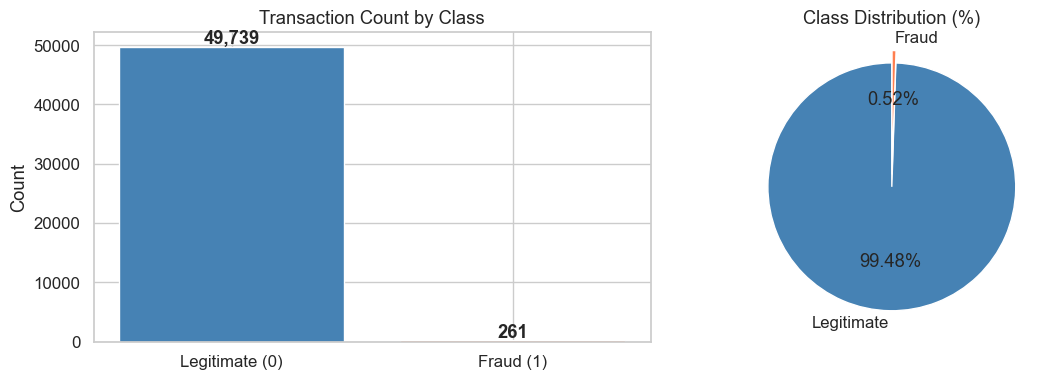

Imbalance ratio: 1:190


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Count
counts = df['is_fraud'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['steelblue','coral'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')

# Percentage
axes[1].pie(counts.values, labels=['Legitimate','Fraud'], autopct='%1.2f%%',
            colors=['steelblue','coral'], startangle=90, explode=[0, 0.1])
axes[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.savefig('../outputs/eda_class_distribution.png', dpi=150)
plt.show()
print(f'Imbalance ratio: 1:{counts[0]//counts[1]}')


### 6.3 Fraud Rate by Category


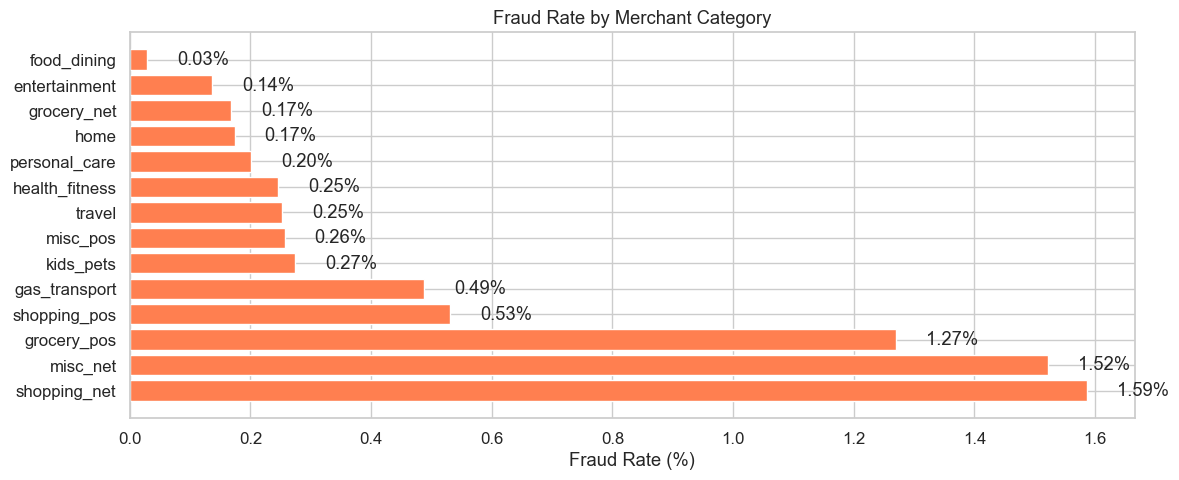

In [8]:
fraud_by_cat = df.groupby('category')['is_fraud'].agg(['mean','count']).sort_values('mean', ascending=False)
fraud_by_cat['mean'] = fraud_by_cat['mean'] * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(fraud_by_cat.index, fraud_by_cat['mean'], color='coral')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Merchant Category')
for bar, val in zip(bars, fraud_by_cat['mean']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center')
plt.tight_layout()
plt.savefig('../outputs/eda_fraud_by_category.png', dpi=150)
plt.show()


### 6.4 Temporal Patterns


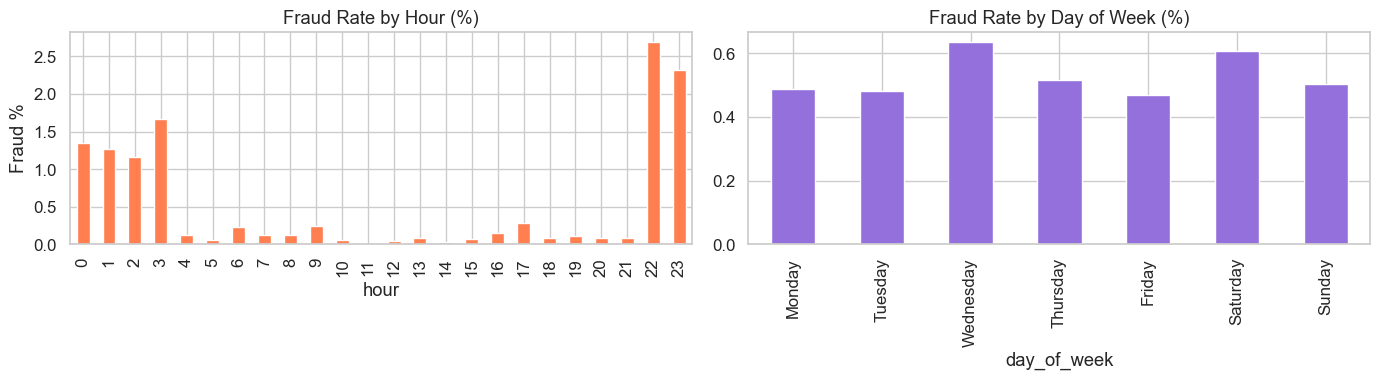

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
fraud_by_hour.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Fraud Rate by Hour (%)')
axes[0].set_ylabel('Fraud %')
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fraud_by_dow = df.groupby('day_of_week')['is_fraud'].mean().reindex(dow_order) * 100
fraud_by_dow.plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Fraud Rate by Day of Week (%)')
plt.tight_layout()
plt.savefig('../outputs/eda_temporal.png', dpi=150)
plt.show()


### 6.5 Numerical Feature Distributions by Fraud Status


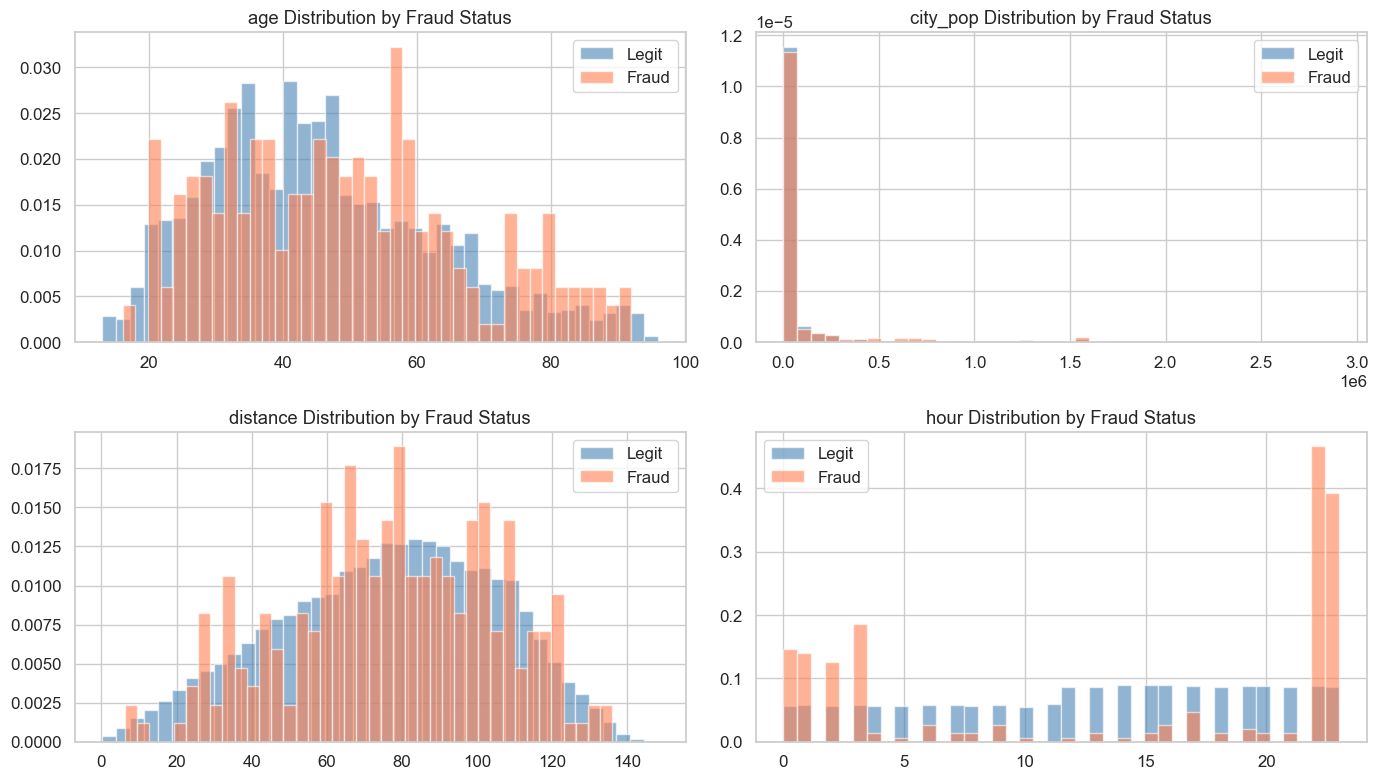

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ['age','city_pop','distance','hour']):
    for label, color in [(0,'steelblue'),(1,'coral')]:
        subset = df[df['is_fraud']==label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=f'{"Fraud" if label else "Legit"}', density=True)
    ax.set_title(f'{col} Distribution by Fraud Status')
    ax.legend()
plt.tight_layout()
plt.savefig('../outputs/eda_distributions.png', dpi=150)
plt.show()


### 6.6 Correlation Heatmap


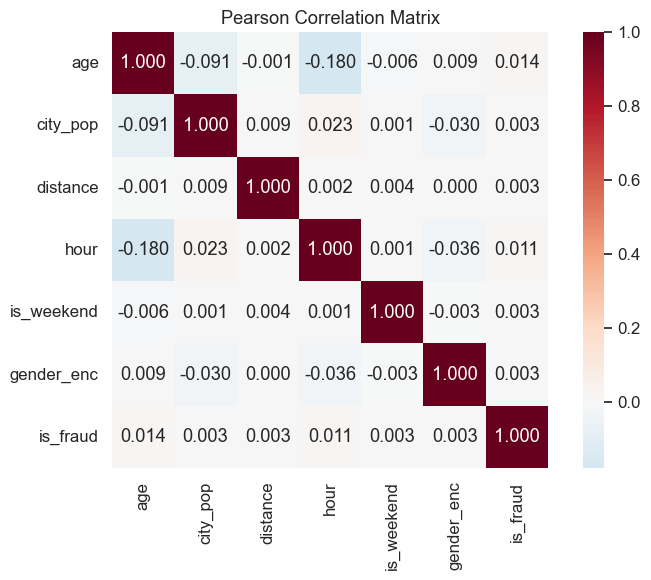

In [11]:
num_cols = ['age','city_pop','distance','hour','is_weekend','gender_enc','is_fraud']
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, square=True)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()


---
## Stage 7 · Classification Data Preparation
### 7.1 Feature Matrix Construction


In [12]:
# One-hot encode category (X1) — drop_first to avoid multicollinearity
cat_dummies = pd.get_dummies(df['category'], prefix='cat', drop_first=True).astype(int)

# One-hot encode day_of_week (X6)
dow_dummies = pd.get_dummies(df['day_of_week'], prefix='dow', drop_first=True).astype(int)

# Numerical features: gender_enc (X2), age (X3), city_pop (X4), hour (X5), is_weekend (X7), distance (X8), amt (X9)
num_features = df[['gender_enc', 'age', 'city_pop', 'hour', 'is_weekend', 'distance', 'amt']]

# Combine all features
X = pd.concat([cat_dummies, dow_dummies, num_features], axis=1).astype(float)
y = df['is_fraud']

print(f'Feature matrix shape: {X.shape}')
print(f'Features ({X.shape[1]} total):')
print(f'  - Category dummies: {cat_dummies.shape[1]}')
print(f'  - Day-of-week dummies: {dow_dummies.shape[1]}')
print(f'  - Numerical: gender_enc, age, city_pop, hour, is_weekend, distance, amt')
print(f'\nClass distribution:\n{y.value_counts().to_string()}')


Feature matrix shape: (50000, 26)
Features (26 total):
  - Category dummies: 13
  - Day-of-week dummies: 6
  - Numerical: gender_enc, age, city_pop, hour, is_weekend, distance, amt

Class distribution:
is_fraud
0    49739
1      261


### 7.2 Stratified Train-Test Split (80:20)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train fraud rate: {y_train.mean()*100:.2f}%')
print(f'Test  fraud rate: {y_test.mean()*100:.2f}%')


Train: 40,000 | Test: 10,000
Train fraud rate: 0.52%
Test  fraud rate: 0.52%


### 7.3 Standardization (Z-score)


In [14]:
# Standardization is critical for KNN (distance-based) and beneficial for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'Scaled train shape: {X_train_scaled.shape}')
print(f'Scaled test shape:  {X_test_scaled.shape}')


Scaled train shape: (40000, 26)
Scaled test shape:  (10000, 26)


### 7.4 SMOTE Oversampling (Training Data Only)


In [15]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'Before SMOTE: {len(X_train_scaled):,} samples')
print(f'After  SMOTE: {len(X_train_smote):,} samples')
print(f'\nClass distribution after SMOTE:')
print(pd.Series(y_train_smote).value_counts().to_string())
print(f'\n⚠️ SMOTE applied ONLY to training data. Test set remains unmodified.')


Before SMOTE: 40,000 samples
After  SMOTE: 79,582 samples

Class distribution after SMOTE:
is_fraud
0    39791
1    39791

⚠️ SMOTE applied ONLY to training data. Test set remains unmodified.


---
## Stage 8 · KNN Classification — Baseline (No SMOTE)
### 8.1 Optimal k Selection via 5-Fold Stratified CV


In [16]:
k_candidates = [1, 3, 5, 7, 9, 11, 15, 21]
cv_results_knn = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for k in k_candidates:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring='f1')
    cv_results_knn.append({'k': k, 'mean_f1': scores.mean(), 'std_f1': scores.std()})
    print(f'k={k:2d} → F1={scores.mean():.4f} ± {scores.std():.4f}')

best_k_base = max(cv_results_knn, key=lambda x: x['mean_f1'])['k']
print(f'\n✅ Best k (baseline): {best_k_base}')


k= 1 → F1=0.3588 ± 0.0657


k= 3 → F1=0.2673 ± 0.0664


k= 5 → F1=0.2230 ± 0.0702


k= 7 → F1=0.2268 ± 0.0636


k= 9 → F1=0.2073 ± 0.0577


k=11 → F1=0.1638 ± 0.0718


k=15 → F1=0.1373 ± 0.0393


k=21 → F1=0.0863 ± 0.0720

✅ Best k (baseline): 1


### 8.2 KNN Baseline — Train & Evaluate


In [17]:
knn_base = KNeighborsClassifier(n_neighbors=best_k_base)
knn_base.fit(X_train_scaled, y_train)
y_pred_knn_base = knn_base.predict(X_test_scaled)
y_prob_knn_base = knn_base.predict_proba(X_test_scaled)[:, 1]

print('=== KNN Baseline (No SMOTE) ===')
print(f'k = {best_k_base}\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn_base))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn_base, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_knn_base):.4f}')


=== KNN Baseline (No SMOTE) ===
k = 1

Confusion Matrix:
[[9927   21]
 [  33   19]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      9948
       Fraud       0.47      0.37      0.41        52

    accuracy                           0.99     10000
   macro avg       0.74      0.68      0.71     10000
weighted avg       0.99      0.99      0.99     10000

ROC-AUC: 0.6816


---
## Stage 9 · KNN Classification — With SMOTE
### 9.1 Optimal k Selection via 5-Fold Stratified CV (SMOTE inside CV)


In [18]:
# Use imblearn Pipeline to apply SMOTE inside each CV fold (prevents data leakage)
cv_results_knn_smote = []
for k in k_candidates:
    pipe = ImbPipeline([('smote', SMOTE(random_state=SEED)),
                        ('knn', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1')
    cv_results_knn_smote.append({'k': k, 'mean_f1': scores.mean(), 'std_f1': scores.std()})
    print(f'k={k:2d} → F1={scores.mean():.4f} ± {scores.std():.4f}')

best_k_smote = max(cv_results_knn_smote, key=lambda x: x['mean_f1'])['k']
print(f'\n✅ Best k (SMOTE): {best_k_smote}')


k= 1 → F1=0.3921 ± 0.0777


k= 3 → F1=0.3610 ± 0.0624


k= 5 → F1=0.3195 ± 0.0572


k= 7 → F1=0.3038 ± 0.0569


k= 9 → F1=0.2751 ± 0.0530


k=11 → F1=0.2540 ± 0.0498


k=15 → F1=0.2237 ± 0.0387


k=21 → F1=0.1944 ± 0.0335

✅ Best k (SMOTE): 1


### 9.2 KNN + SMOTE — Train & Evaluate


In [19]:
knn_smote = KNeighborsClassifier(n_neighbors=best_k_smote)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test_scaled)
y_prob_knn_smote = knn_smote.predict_proba(X_test_scaled)[:, 1]

print('=== KNN + SMOTE ===')
print(f'k = {best_k_smote}\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn_smote))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn_smote, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_knn_smote):.4f}')


=== KNN + SMOTE ===
k = 1

Confusion Matrix:
[[9901   47]
 [  31   21]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      9948
       Fraud       0.31      0.40      0.35        52

    accuracy                           0.99     10000
   macro avg       0.65      0.70      0.67     10000
weighted avg       0.99      0.99      0.99     10000

ROC-AUC: 0.6996


---
## Stage 10 · Logistic Regression — Baseline (No SMOTE)


In [20]:
lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
lr_base.fit(X_train_scaled, y_train)
y_pred_lr_base = lr_base.predict(X_test_scaled)
y_prob_lr_base = lr_base.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression Baseline (No SMOTE) ===\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr_base))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_base, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr_base):.4f}')


=== Logistic Regression Baseline (No SMOTE) ===

Confusion Matrix:
[[9948    0]
 [  52    0]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      9948
       Fraud       0.00      0.00      0.00        52

    accuracy                           0.99     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.99      0.99      0.99     10000

ROC-AUC: 0.7617


---
## Stage 11 · Logistic Regression — With SMOTE


In [21]:
lr_smote = LogisticRegression(max_iter=1000, random_state=SEED)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_prob_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression + SMOTE ===\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr_smote))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_smote, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr_smote):.4f}')


=== Logistic Regression + SMOTE ===

Confusion Matrix:
[[8478 1470]
 [  14   38]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.85      0.92      9948
       Fraud       0.03      0.73      0.05        52

    accuracy                           0.85     10000
   macro avg       0.51      0.79      0.48     10000
weighted avg       0.99      0.85      0.91     10000

ROC-AUC: 0.8834


---
## Stage 12 · Comparative Analysis
### 12.1 Performance Comparison Table


In [22]:
# Collect metrics for all 4 models
models = {
    'KNN Baseline':   (y_pred_knn_base,  y_prob_knn_base),
    'KNN + SMOTE':    (y_pred_knn_smote, y_prob_knn_smote),
    'LR Baseline':    (y_pred_lr_base,   y_prob_lr_base),
    'LR + SMOTE':     (y_pred_lr_smote,  y_prob_lr_smote),
}

results = []
for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision (Fraud)': precision_score(y_test, y_pred),
        'Recall (Fraud)':    recall_score(y_test, y_pred),
        'F1 (Fraud)':        f1_score(y_test, y_pred),
        'ROC-AUC':           roc_auc_score(y_test, y_prob),
    })

df_results = pd.DataFrame(results).set_index('Model')
print('═' * 80)
print('COMPARATIVE PERFORMANCE — ALL 4 MODELS')
print('═' * 80)
print(df_results.round(4).to_string())
print()
print(f'🏆 Best F1 (Fraud):  {df_results["F1 (Fraud)"].idxmax()} ({df_results["F1 (Fraud)"].max():.4f})')
print(f'🏆 Best Recall (Fraud): {df_results["Recall (Fraud)"].idxmax()} ({df_results["Recall (Fraud)"].max():.4f})')
print(f'🏆 Best ROC-AUC:     {df_results["ROC-AUC"].idxmax()} ({df_results["ROC-AUC"].max():.4f})')


════════════════════════════════════════════════════════════════════════════════
COMPARATIVE PERFORMANCE — ALL 4 MODELS
════════════════════════════════════════════════════════════════════════════════
              Accuracy  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  ROC-AUC
Model                                                                         
KNN Baseline    0.9946             0.4750          0.3654      0.4130   0.6816
KNN + SMOTE     0.9922             0.3088          0.4038      0.3500   0.6996
LR Baseline     0.9948             0.0000          0.0000      0.0000   0.7617
LR + SMOTE      0.8516             0.0252          0.7308      0.0487   0.8834

🏆 Best F1 (Fraud):  KNN Baseline (0.4130)
🏆 Best Recall (Fraud): LR + SMOTE (0.7308)
🏆 Best ROC-AUC:     LR + SMOTE (0.8834)


### 12.2 ROC Curves — All Models


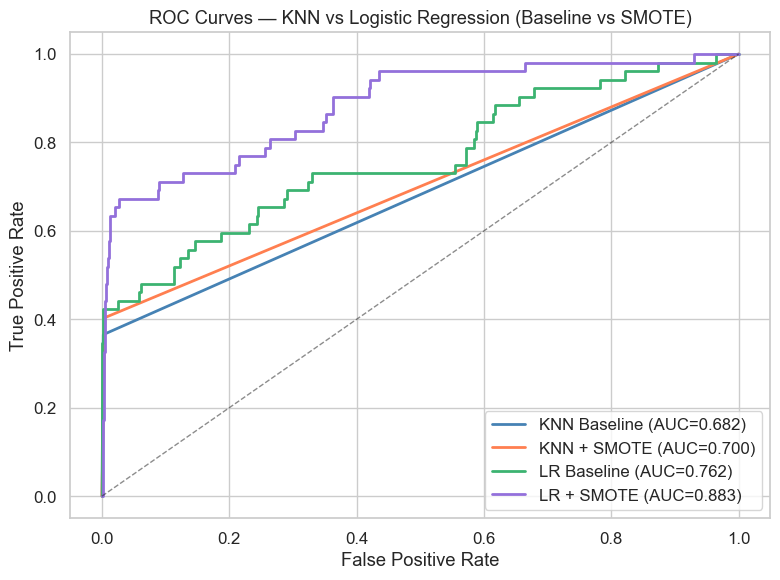

In [23]:
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for (name, (_, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — KNN vs Logistic Regression (Baseline vs SMOTE)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_curves_comparison.png', dpi=150)
plt.show()


### 12.3 Confusion Matrix Grid


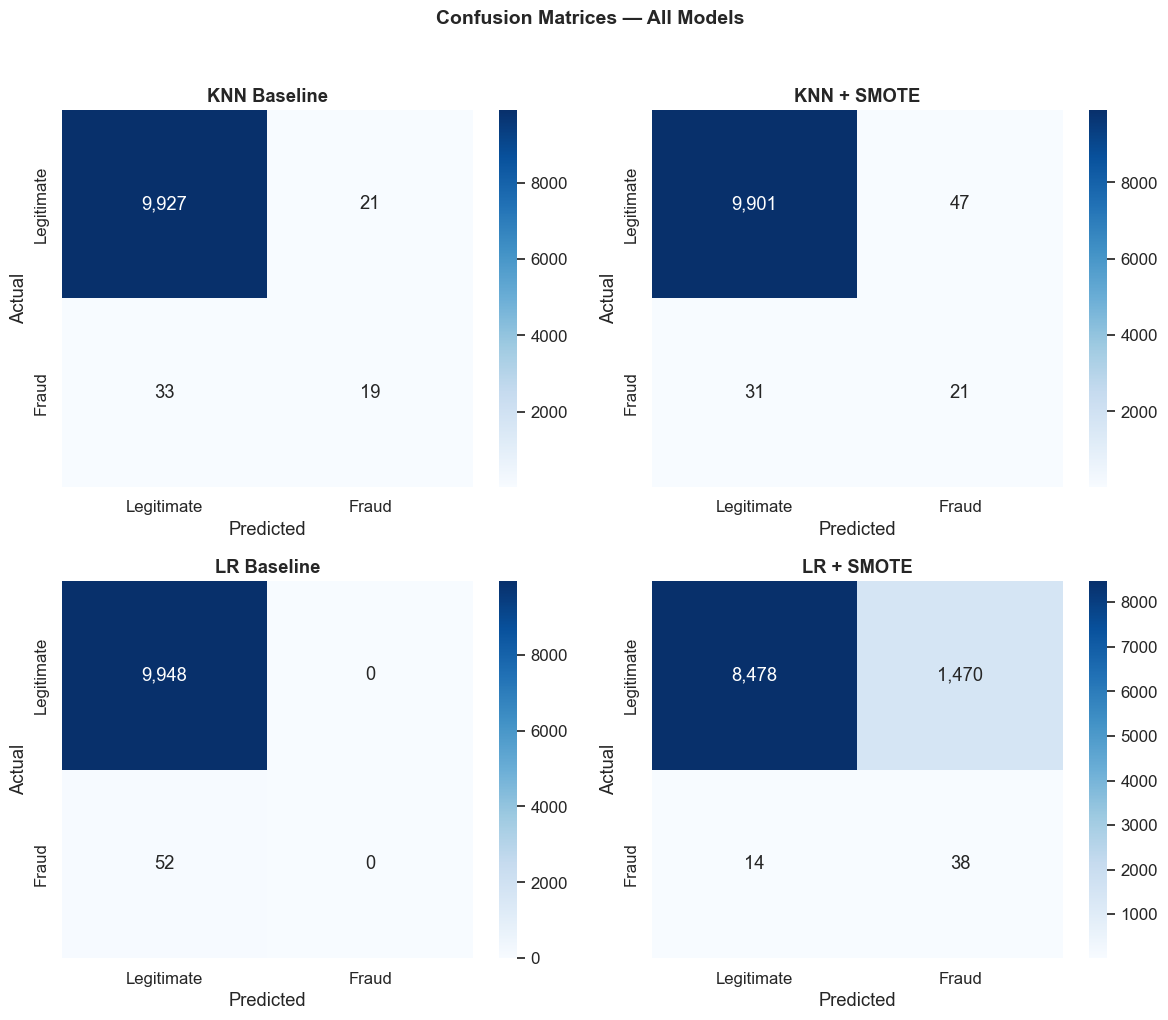

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, (y_pred, _)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150)
plt.show()


### 12.4 F1 & Recall Comparison (Bar Chart)


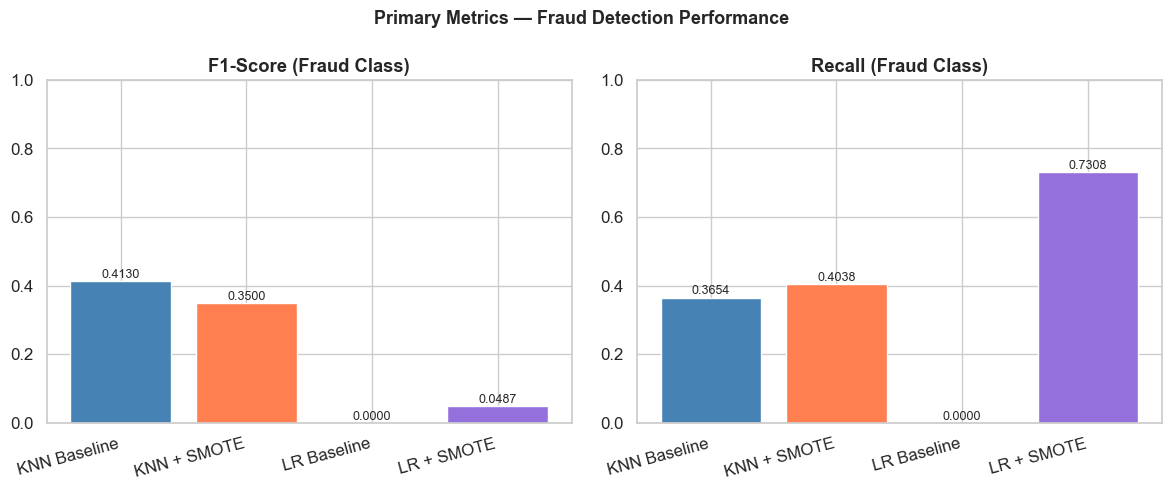

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = df_results.index.tolist()
x = range(len(model_names))

# F1
bars1 = axes[0].bar(x, df_results['F1 (Fraud)'], color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_title('F1-Score (Fraud Class)', fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, df_results['F1 (Fraud)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontsize=9)

# Recall
bars2 = axes[1].bar(x, df_results['Recall (Fraud)'], color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].set_title('Recall (Fraud Class)', fontweight='bold')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, df_results['Recall (Fraud)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Primary Metrics — Fraud Detection Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/f1_recall_comparison.png', dpi=150)
plt.show()


### 12.5 SMOTE Impact Analysis


In [26]:
print('═' * 60)
print('SMOTE IMPACT ANALYSIS')
print('═' * 60)

for algo in ['KNN', 'LR']:
    base_name = f'{algo} Baseline'
    smote_name = f'{algo} + SMOTE'
    print(f'\n--- {algo} ---')
    for metric in ['Accuracy', 'Precision (Fraud)', 'Recall (Fraud)', 'F1 (Fraud)', 'ROC-AUC']:
        base_val  = df_results.loc[base_name, metric]
        smote_val = df_results.loc[smote_name, metric]
        delta = smote_val - base_val
        arrow = '↑' if delta > 0 else '↓' if delta < 0 else '→'
        print(f'  {metric:20s}: {base_val:.4f} → {smote_val:.4f} ({arrow} {abs(delta):.4f})')


════════════════════════════════════════════════════════════
SMOTE IMPACT ANALYSIS
════════════════════════════════════════════════════════════

--- KNN ---
  Accuracy            : 0.9946 → 0.9922 (↓ 0.0024)
  Precision (Fraud)   : 0.4750 → 0.3088 (↓ 0.1662)
  Recall (Fraud)      : 0.3654 → 0.4038 (↑ 0.0385)
  F1 (Fraud)          : 0.4130 → 0.3500 (↓ 0.0630)
  ROC-AUC             : 0.6816 → 0.6996 (↑ 0.0179)

--- LR ---
  Accuracy            : 0.9948 → 0.8516 (↓ 0.1432)
  Precision (Fraud)   : 0.0000 → 0.0252 (↑ 0.0252)
  Recall (Fraud)      : 0.0000 → 0.7308 (↑ 0.7308)
  F1 (Fraud)          : 0.0000 → 0.0487 (↑ 0.0487)
  ROC-AUC             : 0.7617 → 0.8834 (↑ 0.1217)


### 12.6 · Threshold Tuning
The default 0.5 cut-off is rarely optimal for imbalanced data — it is why some models
score 0 recall despite a strong ROC-AUC. Here we instead pick, for each model, the
decision threshold that **maximises the fraud-class F1**, read off the precision–recall
curve of its predicted probabilities. The test set is untouched; only the cut-off changes.


In [27]:
from sklearn.metrics import precision_recall_curve

def best_f1_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    i = int(np.argmax(f1))
    return thr[i], prec[i], rec[i], f1[i]

tuned = []
for name, (_, y_prob) in models.items():
    t, p, r, f = best_f1_threshold(y_test, y_prob)
    tuned.append({'Model': name,
                  'Default F1': df_results.loc[name, 'F1 (Fraud)'],
                  'Tuned thr': t,
                  'Tuned Precision': p,
                  'Tuned Recall': r,
                  'Tuned F1': f})
df_tuned = pd.DataFrame(tuned).set_index('Model')

print('═' * 78)
print('THRESHOLD TUNING — operating point that maximises fraud-class F1')
print('═' * 78)
print(df_tuned.round(4).to_string())
print()
for name in ['LR Baseline', 'LR + SMOTE']:
    print(f"{name}: F1 {df_results.loc[name,'F1 (Fraud)']:.4f} (thr=0.50) "
          f"→ {df_tuned.loc[name,'Tuned F1']:.4f} (thr={df_tuned.loc[name,'Tuned thr']:.3f})")
print('\nNote: KNN uses k=1, so its predicted probabilities are ~binary (0/1) and barely'
      ' respond to thresholding — tuning mainly benefits Logistic Regression.')


══════════════════════════════════════════════════════════════════════════════
THRESHOLD TUNING — operating point that maximises fraud-class F1
══════════════════════════════════════════════════════════════════════════════
              Default F1  Tuned thr  Tuned Precision  Tuned Recall  Tuned F1
Model                                                                       
KNN Baseline      0.4130     1.0000           0.4750        0.3654    0.4130
KNN + SMOTE       0.3500     1.0000           0.3088        0.4038    0.3500
LR Baseline       0.0000     0.0999           0.8182        0.3462    0.4865
LR + SMOTE        0.0487     0.9290           0.3000        0.4615    0.3636

LR Baseline: F1 0.0000 (thr=0.50) → 0.4865 (thr=0.100)
LR + SMOTE: F1 0.0487 (thr=0.50) → 0.3636 (thr=0.929)

Note: KNN uses k=1, so its predicted probabilities are ~binary (0/1) and barely respond to thresholding — tuning mainly benefits Logistic Regression.


### 12.6b · Precision–Recall Curves


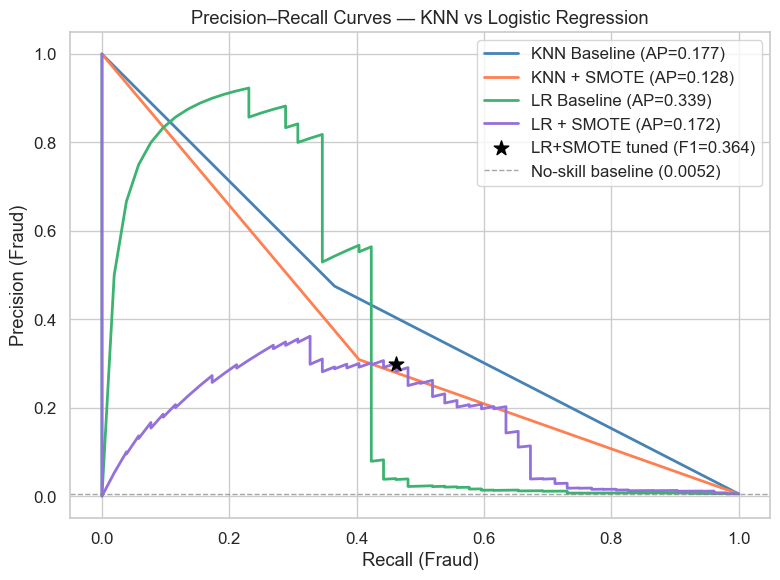

In [28]:
from sklearn.metrics import average_precision_score

plt.figure(figsize=(8, 6))
for (name, (_, y_prob)), color in zip(models.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

# Mark the tuned LR + SMOTE operating point (max-F1)
plt.scatter([df_tuned.loc['LR + SMOTE', 'Tuned Recall']],
            [df_tuned.loc['LR + SMOTE', 'Tuned Precision']],
            color='black', zorder=5, s=120, marker='*',
            label=f"LR+SMOTE tuned (F1={df_tuned.loc['LR + SMOTE','Tuned F1']:.3f})")
base_rate = y_test.mean()
plt.axhline(base_rate, ls='--', color='grey', lw=1, alpha=0.7,
            label=f'No-skill baseline ({base_rate:.4f})')
plt.xlabel('Recall (Fraud)')
plt.ylabel('Precision (Fraud)')
plt.title('Precision–Recall Curves — KNN vs Logistic Regression')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/precision_recall_curves.png', dpi=150)
plt.show()


---
## Stage 13 · Summary & Conclusion
### 13.1 Final Results Table (auto-generated from the run)


In [29]:
from IPython.display import display, Markdown

print('FINAL RESULTS — All 4 Models')
display(df_results.round(4))

best_f1  = df_results['F1 (Fraud)'].idxmax()
best_rec = df_results['Recall (Fraud)'].idxmax()
best_auc = df_results['ROC-AUC'].idxmax()

lines = ['**Key findings (computed):**', '']
lines.append(f"- Best **F1 (fraud)**: `{best_f1}` ({df_results.loc[best_f1,'F1 (Fraud)']:.4f})")
lines.append(f"- Best **Recall (fraud)**: `{best_rec}` ({df_results.loc[best_rec,'Recall (Fraud)']:.4f})")
lines.append(f"- Best **ROC-AUC**: `{best_auc}` ({df_results.loc[best_auc,'ROC-AUC']:.4f})")
for algo in ['KNN', 'LR']:
    d_f1  = df_results.loc[f'{algo} + SMOTE','F1 (Fraud)']     - df_results.loc[f'{algo} Baseline','F1 (Fraud)']
    d_rec = df_results.loc[f'{algo} + SMOTE','Recall (Fraud)'] - df_results.loc[f'{algo} Baseline','Recall (Fraud)']
    lines.append(f"- **SMOTE effect on {algo}**: F1 {d_f1:+.4f}, Recall {d_rec:+.4f}")
display(Markdown('\n'.join(lines)))


FINAL RESULTS — All 4 Models


,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC
Model,,,,,
KNN Baseline,0.9946,0.4750,0.3654,0.4130,0.6816
KNN + SMOTE,0.9922,0.3088,0.4038,0.3500,0.6996
LR Baseline,0.9948,0.0000,0.0000,0.0000,0.7617
LR + SMOTE,0.8516,0.0252,0.7308,0.0487,0.8834


**Key findings (computed):**

- Best **F1 (fraud)**: `KNN Baseline` (0.4130)
- Best **Recall (fraud)**: `LR + SMOTE` (0.7308)
- Best **ROC-AUC**: `LR + SMOTE` (0.8834)
- **SMOTE effect on KNN**: F1 -0.0630, Recall +0.0385
- **SMOTE effect on LR**: F1 +0.0487, Recall +0.7308

### 13.2 Research Questions Answered

**Default-threshold results (50K stratified subsample, 0.52% fraud, test set ≈ 52 fraud cases, 9 features incl. `amt`):**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| KNN Baseline | 0.9946 | 0.4750 | 0.3654 | 0.4130 | 0.6816 |
| KNN + SMOTE | 0.9922 | 0.3088 | 0.4038 | 0.3500 | 0.6996 |
| LR Baseline | 0.9948 | 0.0000 | 0.0000 | 0.0000 | 0.7617 |
| LR + SMOTE | 0.8516 | 0.0252 | **0.7308** | 0.0487 | **0.8834** |

**Tuned-threshold results (cut-off chosen to maximise fraud-class F1 — Stage 12.6):**

| Model | Threshold | Precision | Recall | F1 |
|---|---|---|---|---|
| KNN Baseline | 1.00 | 0.4750 | 0.3654 | 0.4130 |
| KNN + SMOTE | 1.00 | 0.3088 | 0.4038 | 0.3500 |
| LR Baseline | **0.10** | **0.8182** | 0.3462 | **0.4865** |
| LR + SMOTE | 0.93 | 0.3000 | 0.4615 | 0.3636 |

**1. Which algorithm performs best?**

**Logistic Regression is the stronger algorithm on every front once the decision threshold is treated as a tunable knob:**

- At its **tuned threshold (≈0.10), LR Baseline gives the best F1 of any model (0.487)** with high precision (0.818) — and it does so **without SMOTE**. The "useless" zero-recall baseline was never broken; only the default 0.5 cut-off was wrong for a 0.5%-fraud problem.
- **LR + SMOTE** still owns the best **recall (0.731)** and best **ROC-AUC (0.884)** — the right choice when the goal is to catch as much fraud as possible.
- **KNN is not competitive:** lower ROC-AUC (0.68–0.70), and because the optimal k=1 produces near-binary probabilities, **its threshold cannot be tuned** (tuned ≈ default). Its best F1 (0.413) trails tuned LR.

**Verdict → Logistic Regression.** Use **LR Baseline at threshold ≈ 0.10** for the best precision/recall balance (F1 0.49, precision 0.82), or **LR + SMOTE** when maximum fraud capture (recall 0.73) is the priority.

**2. How does SMOTE affect relative performance?**

- **At the default 0.5 threshold SMOTE looks essential for LR** — it lifts recall 0.000 → 0.731 and ROC-AUC 0.762 → 0.883. But this is largely because SMOTE *implicitly shifts the decision boundary*, and **threshold tuning achieves the same goal more effectively.** Tuned LR Baseline (F1 0.487) beats tuned LR + SMOTE (F1 0.364): once the cut-off is tuned, SMOTE no longer helps F1 and even lowers precision.
- **For KNN, SMOTE is mildly harmful** (F1 0.413 → 0.350): it already captures local fraud structure via `amt`, so the synthetic points mostly add false positives; ROC-AUC barely moves.
- **Takeaway:** SMOTE and threshold tuning are two routes to the same end — rebalancing the minority decision. For this dataset **threshold tuning is the more powerful and cheaper lever**; SMOTE's main residual value is maximising recall.

### Recommendation

**Deploy Logistic Regression and tune the threshold rather than relying on SMOTE.** A tuned LR Baseline (cut-off ≈ 0.10) delivers the best balanced performance (F1 0.49, precision 0.82, recall 0.35); if the business priority is catching the maximum number of frauds, LR + SMOTE at the default threshold reaches recall 0.73 (at the cost of many false positives). KNN is not recommended here: weaker ranking ability and, at k=1, no usable probability scores to tune.

### Limitations & Future Work

- **Adding `amt` (X9) was decisive.** Versus the 8-feature version, KNN's ROC-AUC rose 0.51 → 0.68 and its F1 0.04 → 0.41, and LR + SMOTE's ROC-AUC rose 0.75 → 0.88 — confirming transaction amount is the dominant fraud signal.
- **KNN probabilities are degenerate at k=1**, which prevents threshold tuning; calibrated scores (distance-weighted voting, a larger k, or Platt scaling) would make KNN tunable and a fairer comparison.
- **`amt` is highly right-skewed**, which can let outliers dominate KNN's Euclidean distances even after z-scoring; a log transform before scaling may further help KNN.
- **Moderate fraud count.** At 50K the test set holds ~52 fraud cases; 100K–200K would tighten the estimates (at materially higher KNN cross-validation cost).
